# Face recognition with ChimUFE

## Computation

### 1. Install & Imports

In [1]:
import os
from pathlib import Path
import sys
import torch
import numpy as np
from PIL import Image
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

# Optional: notebook widgets
from IPython.display import display
import ipywidgets as widgets

# Imports for ChimpUFE
sys.path.append("../Tracking/ChimpUFE/src")  # Path to ChimpUFE, adjust if needed
from face_embedder.vision_transformer import vit_base

# YOLOX imports (from your ChimpUFE tracker module)
from tracker.yolox.models import YOLOX, YOLOPAFPN, YOLOXHead
from tracker.yolox.utils import fuse_model

from sklearn.metrics.pairwise import cosine_similarity

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### 2. Load YOLOX Model

In [2]:
# Path to YOLOX weights
repo_root = "../Tracking/ChimpUFE"
yolox_weights = f"{repo_root}/assets/weights/yolox_best_only_model.pth"

def load_yolox(weights_path, device):
    depth, width = 1.33, 1.25
    in_channels = [256, 512, 1024]
    num_classes = 1
    backbone = YOLOPAFPN(depth, width, in_channels=in_channels)
    head = YOLOXHead(num_classes, width, in_channels=in_channels)
    model = YOLOX(backbone, head)
    model.head.initialize_biases(1e-2)
    ckpt = torch.load(weights_path, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    model = model.to(device).eval()
    model = fuse_model(model)
    return model

yolox_model = load_yolox(yolox_weights, device)

### 3. Crop Faces with YOLOX

In [3]:
chimp_pic_dir = "../../ChimpPic/train"
out_crop_dir = "../../ChimpPic/ChimpPic_face_crops"
os.makedirs(out_crop_dir, exist_ok=True)

face_db = []

def detect_body_yolox(img, yolox_model, device, input_size=(800, 1440), conf_thres=0.3):
    h0, w0 = img.shape[:2]
    r = min(input_size[0] / h0, input_size[1] / w0)
    new_w, new_h = int(w0 * r), int(h0 * r)
    resized = cv2.resize(img, (new_w, new_h))
    padded = np.ones((input_size[0], input_size[1], 3), dtype=np.uint8) * 114
    padded[:new_h, :new_w, :] = resized
    padded = padded.transpose(2,0,1)[None].astype(np.float32)
    padded = torch.from_numpy(padded).to(device).float()
    with torch.no_grad():
        preds = yolox_model(padded)
        pred = preds[0]
        output = []
        for row in pred:
            x_c, y_c, w, h, obj_conf, class_conf = row[:6].cpu().numpy()
            conf = obj_conf * class_conf
            if conf < conf_thres: continue
            x, y = x_c - w/2, y_c - h/2
            x1, y1 = int(x/r), int(y/r)
            x2, y2 = int((x+w)/r), int((y+h)/r)
            output.append([x1, y1, x2, y2, conf])
        return sorted(output, key=lambda x: -x[4])

for chimp_name in sorted(os.listdir(chimp_pic_dir)):
    in_chimp_folder = os.path.join(chimp_pic_dir, chimp_name)
    if not os.path.isdir(in_chimp_folder):
        continue
    out_chimp_folder = os.path.join(out_crop_dir, chimp_name)
    os.makedirs(out_chimp_folder, exist_ok=True)
    files = sorted(os.listdir(in_chimp_folder))
    # tqdm with description for each chimp
    for fname in tqdm(files, desc=chimp_name):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        in_img_path = os.path.join(in_chimp_folder, fname)
        img = cv2.imread(in_img_path)
        if img is None:
            print(f"Could not load {in_img_path}")
            continue
        dets = detect_body_yolox(img, yolox_model, device)
        if not dets:
            print(f"No chimp detected in {in_img_path}")
            continue
        x1, y1, x2, y2, conf = dets[0]
        face_h = int(1 * (y2 - y1))
        delta = int(0.05 * (y2 - y1))
        new_y1 = max(0, y1 + delta)
        new_y2 = min(img.shape[0], new_y1 + face_h)
        face_crop = img[new_y1:new_y2, x1:x2]
        out_path = os.path.join(out_chimp_folder, fname)
        cv2.imwrite(out_path, face_crop)
        face_db.append({
            "chimp_id": chimp_name,
            "crop_path": out_path,
            "orig_img_path": in_img_path
        })

Amadi:  43%|████▎     | 3/7 [00:01<00:02,  1.59it/s]

No chimp detected in ../../ChimpPic/train/Amadi/Amadi1_frame_0237.png


Amadi:  57%|█████▋    | 4/7 [00:02<00:01,  1.62it/s]

No chimp detected in ../../ChimpPic/train/Amadi/Amadi1_frame_0356.png


Ivan:  33%|███▎      | 2/6 [00:01<00:03,  1.31it/s]

...

Kassongo:  75%|███████▌  | 3/4 [00:01<00:00,  1.66it/s]

No chimp detected in ../../ChimpPic/train/Kassongo/Kassongo1_frame_0218.png


Kassongo: 100%|██████████| 4/4 [00:02<00:00,  1.67it/s]


No chimp detected in ../../ChimpPic/train/Kassongo/Kassongo2.jpg


Kira: 100%|██████████| 4/4 [00:02<00:00,  1.57it/s]


### 4. Load ChimpUFE Embedder Model

In [4]:
def get_chimpufe_model(pretrained_weights, device):
    input_size = 224
    model = vit_base(
        img_size=input_size,
        patch_size=14,
        init_values=1e-05,
        ffn_layer='mlp',
        block_chunks=4,
        qkv_bias=True,
        proj_bias=True,
        ffn_bias=True,
        num_register_tokens=0,
        interpolate_offset=0.1,
        interpolate_antialias=False,
    )
    state_dict = torch.load(pretrained_weights, map_location="cpu", weights_only=False)['teacher']
    state_dict = {k.replace("backbone.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device).eval()
    img_transforms = transforms.Compose([
        transforms.Resize(input_size, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    return model, img_transforms

from torchvision import transforms
chimpufe_weights = f"{repo_root}/assets/weights/25-08-29T11-49-28_340k.pth"
chimpufe_model, chimpufe_transform = get_chimpufe_model(chimpufe_weights, device)

### 5. Compute Embeddings

In [5]:
def get_embedding(model, img, transform, device):
    img = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        emb = model(img)
        emb = torch.nn.functional.normalize(emb, p=2, dim=1)
    return emb.squeeze(0).cpu().numpy()

for entry in tqdm(face_db, desc='ChimpUFE Faces'):
    img = Image.open(entry['crop_path']).convert('RGB')
    entry['embedding'] = get_embedding(chimpufe_model, img, chimpufe_transform, device)

ChimpUFE Faces: 100%|██████████| 32/32 [00:02<00:00, 11.12it/s]


### 6. Interactive Top-K Query Cell (Visualization)

Dropdown(description='Chimpanzee:', options=('Amadi', 'Banalia', 'Binasera', 'Djiku', 'Ivan', 'Jeje', 'Kassong…

Dropdown(description='Crop Image:', options=('Amadi1_frame_0051.png', 'Amadi1_frame_0155.png', 'Amadi1_frame_0…

Button(description='Find Top Matches', style=ButtonStyle())

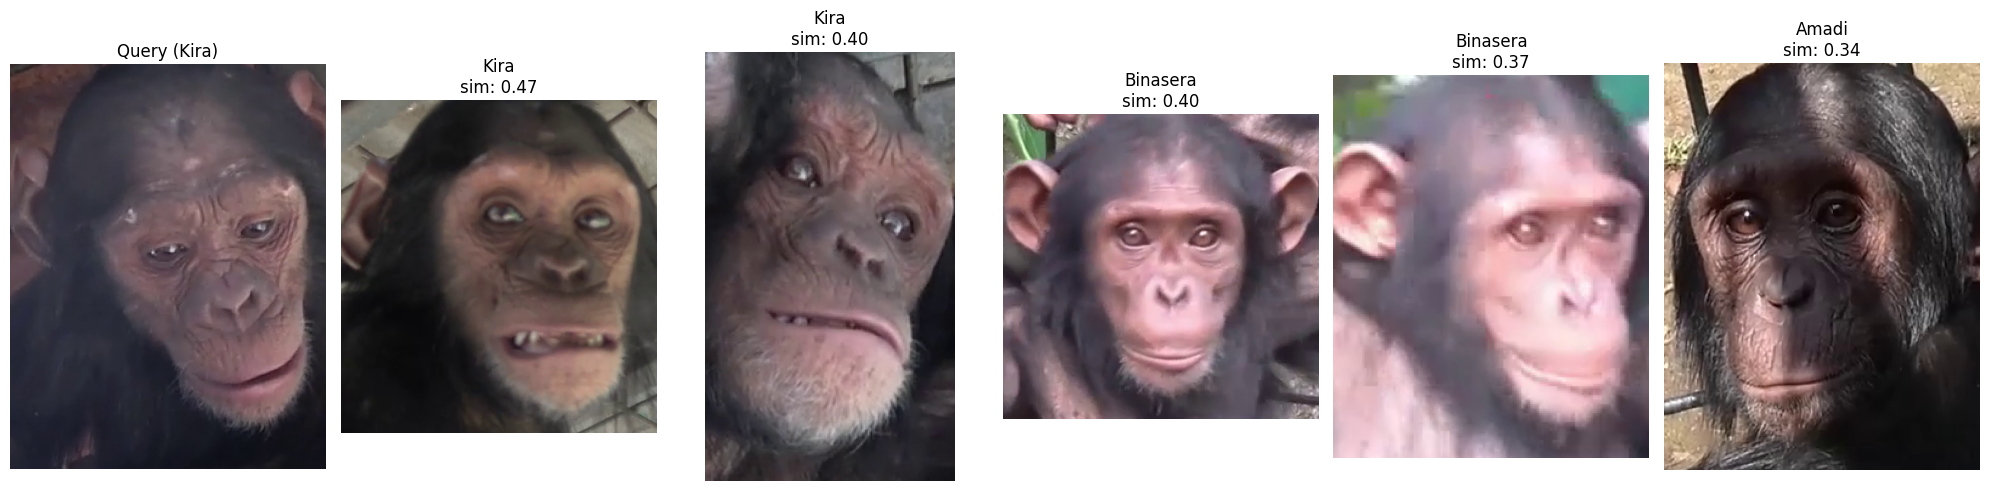

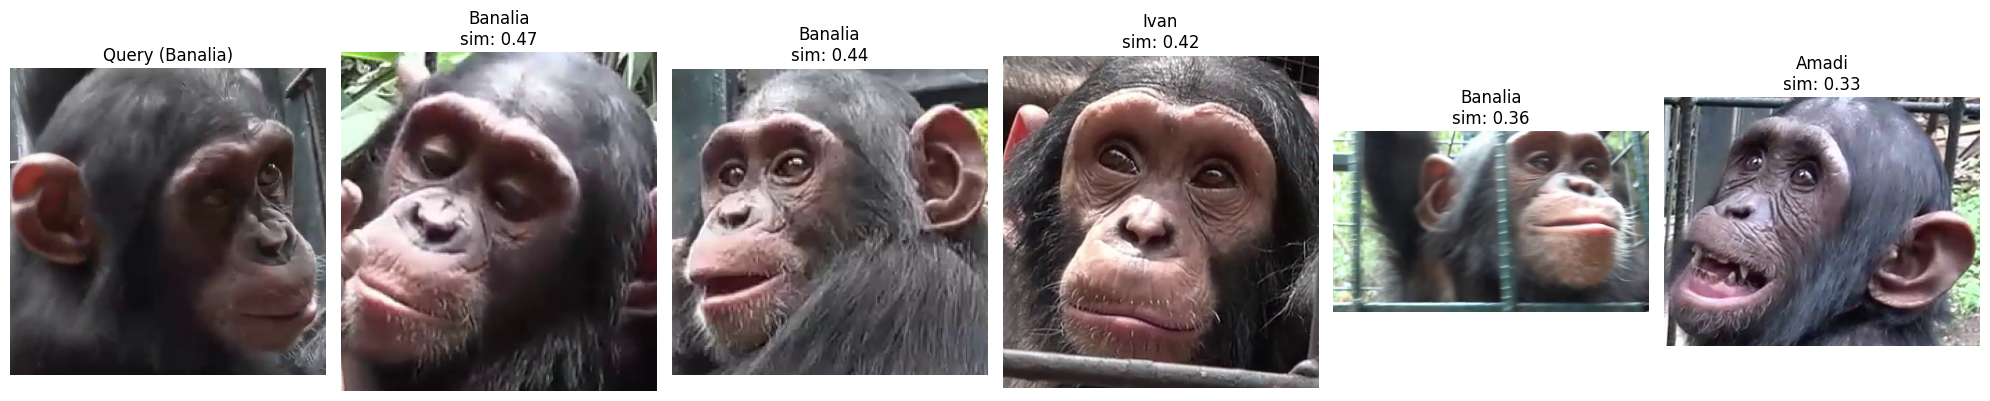

In [6]:
# List all chimpanzee names
chimp_names = sorted(set(entry['chimp_id'] for entry in face_db))

chimp_dropdown = widgets.Dropdown(
    options=chimp_names,
    description="Chimpanzee:",
    value=chimp_names[0]
)

def get_crop_choices(chimp_id):
    crops = sorted(
        [entry for entry in face_db if entry['chimp_id'] == chimp_id],
        key=lambda x: x['crop_path']
    )
    if not crops:
        return ['No images found'], []
    crop_labels = [os.path.basename(entry['crop_path']) for entry in crops]
    return crop_labels, crops

image_dropdown = widgets.Dropdown(options=[''], description="Crop Image:")

def update_image_dropdown(*args):
    query_chimp = chimp_dropdown.value
    crop_labels, crops = get_crop_choices(query_chimp)
    image_dropdown.options = crop_labels
    image_dropdown.value = crop_labels[0] if crop_labels else ''
    image_dropdown.crops = crops

chimp_dropdown.observe(update_image_dropdown, names='value')
update_image_dropdown()

display(chimp_dropdown, image_dropdown)

search_button = widgets.Button(description='Find Top Matches')

def find_top_matches(query_crop, face_db, top_k=10):
    query_emb = get_embedding(chimpufe_model, query_crop, chimpufe_transform, device)
    embs = np.stack([entry['embedding'] for entry in face_db])
    sims = cosine_similarity([query_emb], embs)[0]
    top_idx = np.argsort(sims)[::-1][:top_k]
    return [(face_db[i]['chimp_id'], face_db[i]['crop_path'], sims[i]) for i in top_idx]

def on_search_button_clicked(b):
    chimp = chimp_dropdown.value
    crop_label = image_dropdown.value
    crops = image_dropdown.crops
    for entry in crops:
        if os.path.basename(entry['crop_path']) == crop_label:
            query_entry = entry
            break
    else:
        print("Image not found.")
        return
    query_img = Image.open(query_entry['crop_path'])
    top_matches = find_top_matches(query_img, face_db, top_k=15)
    print(f"Query: {query_entry['crop_path']} | id: {query_entry['chimp_id']}")
    print("\nTop 10 results (excluding self-match):")
    count = 0
    displayable_matches = []
    for i, (chimpid, path, sim) in enumerate(top_matches):
        if path == query_entry['crop_path'] or abs(sim - 1.0) < 1e-5: continue
        count += 1
        print(f"{count:2d}. {chimpid:12s}  {os.path.basename(path):35s}  sim: {sim:.4f}")
        displayable_matches.append((chimpid, path, sim))
        if count >= 10: break
    show_results = displayable_matches[:5]
    fig, axes = plt.subplots(1, 1 + len(show_results), figsize=(20, 5))
    axes[0].imshow(query_img)
    axes[0].set_title(f"Query ({query_entry['chimp_id']})")
    axes[0].axis('off')
    for i, (chimpid, path, sim) in enumerate(show_results):
        img = Image.open(path)
        axes[i+1].imshow(img)
        axes[i+1].set_title(f"{chimpid}\nsim: {sim:.2f}")
        axes[i+1].axis('off')
    plt.tight_layout()
    plt.show()

search_button.on_click(on_search_button_clicked)
display(search_button)

## Results visualisation

### 1. t-SNE & PCA Plot of Embeddings

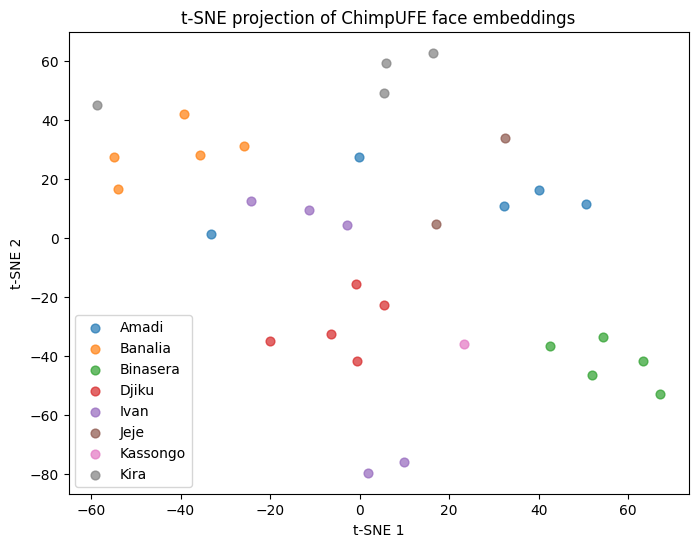

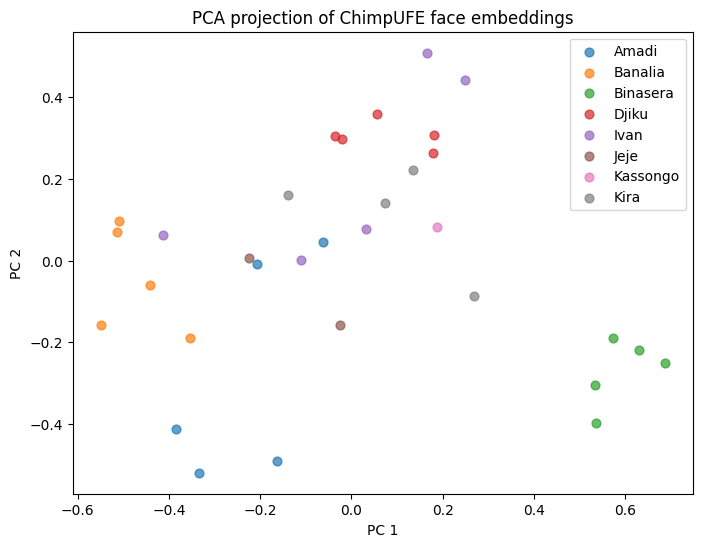

In [7]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# ---- Prepare data ----
embeddings = np.stack([x['embedding'] for x in face_db])
labels = [x['chimp_id'] for x in face_db]
unique_ids = sorted(set(labels))
color_map = {name: i for i, name in enumerate(unique_ids)}
colors = [color_map[l] for l in labels]

# ---- t-SNE ----
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings)//4 or 5))
embeddings_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(8,6))
for chimp in unique_ids:
    idx = [i for i, l in enumerate(labels) if l == chimp]
    plt.scatter(
        embeddings_tsne[idx,0],
        embeddings_tsne[idx,1],
        label=chimp,
        alpha=0.7,
        s=40
    )
plt.legend()
plt.title('t-SNE projection of ChimpUFE face embeddings')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

# ---- PCA ----
pca = PCA(n_components=2)
embeddings_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(8,6))
for chimp in unique_ids:
    idx = [i for i, l in enumerate(labels) if l == chimp]
    plt.scatter(
        embeddings_pca[idx,0],
        embeddings_pca[idx,1],
        label=chimp,
        alpha=0.7,
        s=40
    )
plt.legend()
plt.title('PCA projection of ChimpUFE face embeddings')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()